In [1]:
!pip install tf-nightly-gpu-2.0-preview
import tensorflow as tf

  Preparing metadata (setup.py) ... done
  Created wheel for tf-nightly-gpu-2.0-preview: filename=tf_nightly_gpu_2_0_preview-0.0.0.1-py3-none-any.whl size=1542 sha256=9d645e6df161c5a59293e3979e245892c8c934ecb7841d199cfd47b04eaf9c01
  Stored in directory: /root/.cache/pip/wheels/50/39/2e/a9e8955905c7218ac8015dfd4fa44450c6c2119212c464a01c
Successfully built tf-nightly-gpu-2.0-preview


2026-03-02 19:37:55.052635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772480275.459672      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772480275.578721      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772480276.599532      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772480276.599570      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772480276.599573      24 computation_placer.cc:177] computation placer alr

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import pickle
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# -------------------------------
# GPU Configuration
# -------------------------------
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
print('✅ Found GPU at: {}'.format(device_name))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available and being used.")
else:
    print("❌ No GPU found. Check Kaggle settings.")

✅ Found GPU at: /device:GPU:0
✅ GPU is available and being used.


I0000 00:00:1772480315.944077      24 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772480315.950188      24 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
# -------------------------------
# Configuration
# -------------------------------
CONFIG = {
    'image_size': (224, 224),  # Xception standard input size
    'batch_size': 32,
    'phase1_epochs': 20,  # Frozen base training
    'phase2_epochs': 15,  # Fine-tuning
    'phase1_learning_rate': 0.001,
    'phase2_learning_rate': 0.0001,  # Lower LR for fine-tuning
    'num_classes': 4,
    'seed': 42,
    'base_model_name': 'Xception'
}

In [5]:
# Dataset paths
train_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/train"
val_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/val"
test_path = "/kaggle/input/datasets/shaswatam/epics-lung-disease-dataset/new-lung-disease-dataset/test"

In [6]:
# -------------------------------
# Data Visualization Functions
# -------------------------------
def analyze_dataset(dataset_path, dataset_name):
    """Analyze class distribution in dataset"""
    class_counts = {}
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    
    for class_name in class_names:
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            class_counts[class_name] = len(os.listdir(class_dir))
    
    print(f"\n📊 {dataset_name} Class Distribution:")
    for class_name, count in class_counts.items():
        print(f"   {class_name}: {count} images")
    
    # Plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Disease Classes")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset_name} - Class Distribution")
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts, class_names

In [7]:
def plot_sample_images(dataset, class_names, num_samples=8):
    """Plot sample images from dataset"""
    plt.figure(figsize=(12, 8))
    for images, labels in dataset.take(1):
        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[tf.argmax(labels[i])]
            plt.title(f"True: {true_label}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


📊 Training Set Class Distribution:
   Corona Virus Disease: 1218 images
   Normal: 1207 images
   Pneumonia: 1201 images
   Tuberculosis: 1220 images


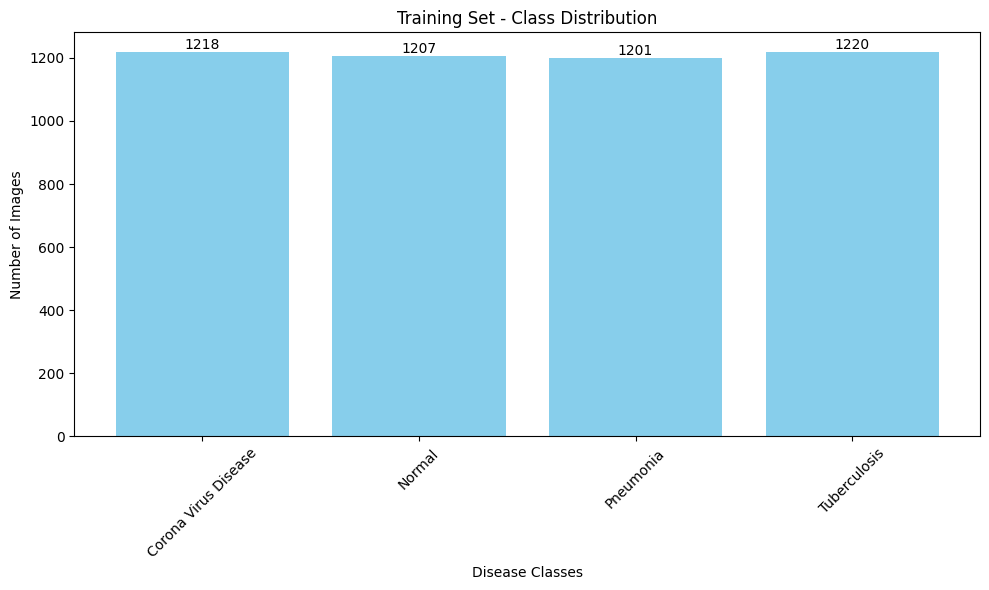


📊 Validation Set Class Distribution:
   Corona Virus Disease: 406 images
   Normal: 402 images
   Pneumonia: 406 images
   Tuberculosis: 406 images


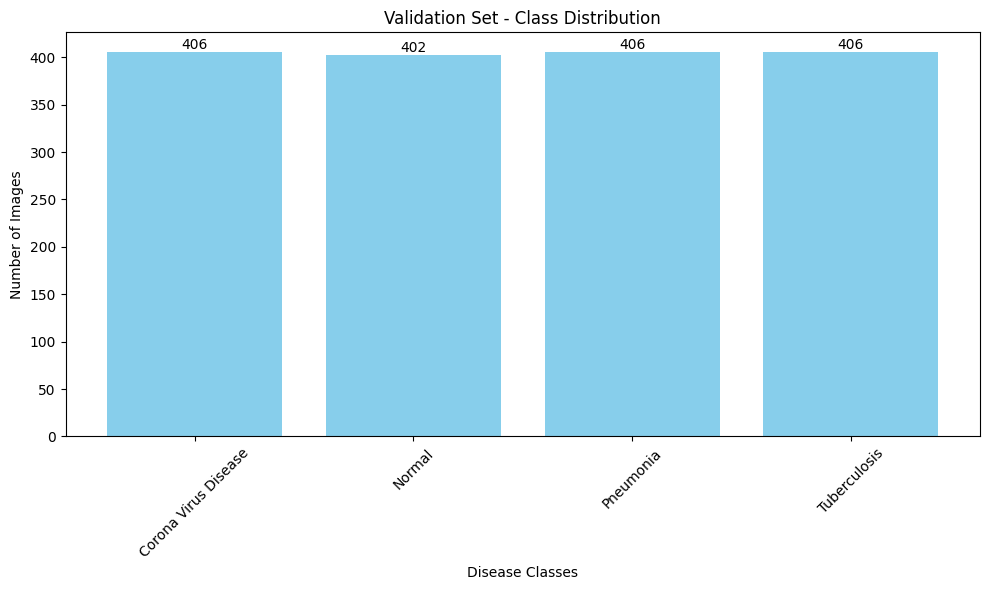


📊 Test Set Class Distribution:
   Corona Virus Disease: 407 images
   Normal: 404 images
   Pneumonia: 402 images
   Tuberculosis: 408 images


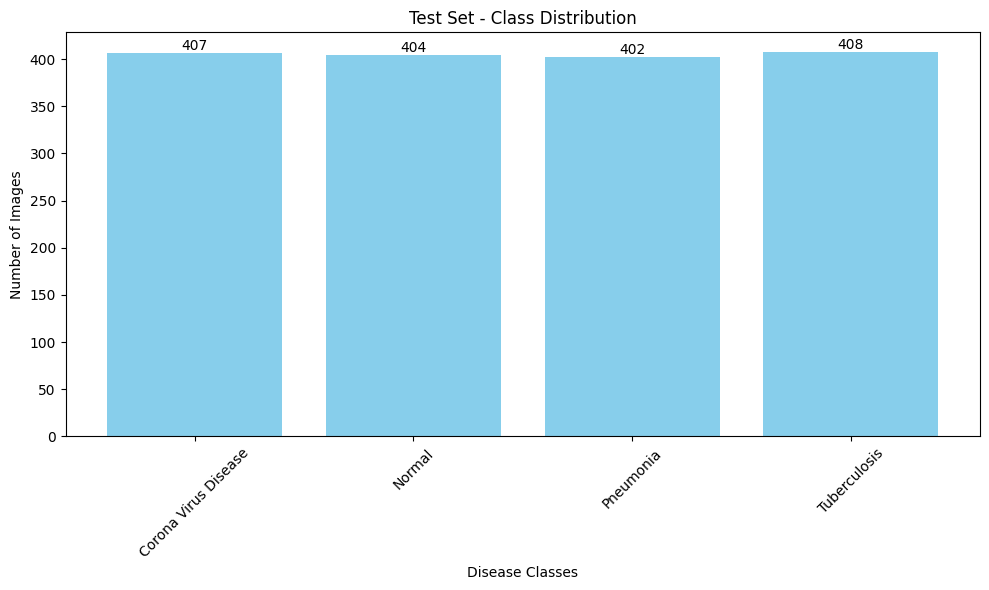

In [8]:
train_counts, class_names = analyze_dataset(train_path, "Training Set")
val_counts, _ = analyze_dataset(val_path, "Validation Set")
test_counts, _ = analyze_dataset(test_path, "Test Set")

In [9]:
def load_datasets():
    """Load training, validation and test datasets"""
    print("\n📁 Loading and preparing datasets...")
    
    # Load datasets using image_dataset_from_directory
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    validation_set = tf.keras.utils.image_dataset_from_directory(
        val_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=True,
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )

    test_set = tf.keras.utils.image_dataset_from_directory(
        test_path,
        labels="inferred",
        label_mode="categorical",
        color_mode="rgb",
        batch_size=CONFIG['batch_size'],
        image_size=CONFIG['image_size'],
        shuffle=False,  # Important for evaluation
        seed=CONFIG['seed'],
        interpolation="bilinear"
    )
    
    return training_set, validation_set, test_set

In [10]:
training_set, validation_set, test_set = load_datasets()
    
# Display dataset information
print(f"📁 Training batches: {len(training_set)}")
print(f"📁 Validation batches: {len(validation_set)}")
print(f"📁 Test batches: {len(test_set)}")


📁 Loading and preparing datasets...
Found 4846 files belonging to 4 classes.


I0000 00:00:1772480321.243030      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772480321.244409      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1620 files belonging to 4 classes.
Found 1621 files belonging to 4 classes.
📁 Training batches: 152
📁 Validation batches: 51
📁 Test batches: 51


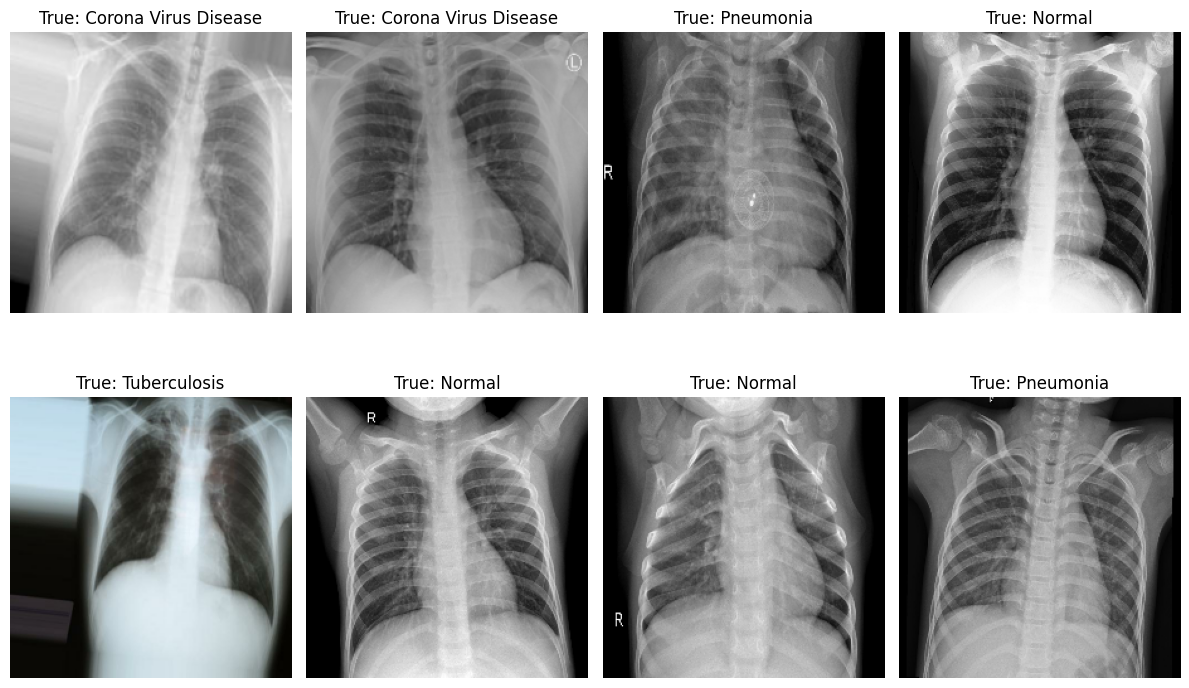

In [11]:
 # Plot sample images
plot_sample_images(training_set, class_names)

In [12]:
def create_xception_model():
    """Create transfer learning model with Xception – accepts 224x224 input."""
    print(f"\n🛠️ Creating Transfer Learning Model with {CONFIG['base_model_name']}...")

    # Base model (original Xception expects 299x299)
    base_model = tf.keras.applications.Xception(
        input_shape=(299, 299, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False

    # New input (224x224)
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Resize to 299x299 (as Xception expects)
    resized = tf.keras.layers.Resizing(299, 299)(inputs)

    # Apply Xception preprocessing
    x = tf.keras.applications.xception.preprocess_input(resized)

    # Pass through base model
    x = base_model(x, training=False)

    # Custom classifier head (unchanged)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(CONFIG['num_classes'], activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

In [13]:
def compile_model(model, learning_rate):
    """Compile the model with optimizer, loss and metrics"""
    print(f"\n⚙️ Compiling Model with learning rate: {learning_rate}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.F1Score(name='f1_score', average='weighted')
        ]
    )
    
    return model

In [14]:
model, base_model = create_xception_model()
model = compile_model(model, CONFIG['phase1_learning_rate'])


🛠️ Creating Transfer Learning Model with Xception...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

⚙️ Compiling Model with learning rate: 0.001


In [15]:
def analyze_xception_layers(base_model):
    """Analyze Xception layer structure for fine-tuning strategy"""
    print(f"\n🔍 Analyzing {CONFIG['base_model_name']} Architecture...")
    
    # Count different types of layers
    conv_layers = [layer for layer in base_model.layers if 'conv' in layer.name]
    sepconv_layers = [layer for layer in base_model.layers if 'separable_conv' in layer.name]
    add_layers = [layer for layer in base_model.layers if 'add' in layer.name]
    bn_layers = [layer for layer in base_model.layers if 'batch_normalization' in layer.name or 'bn' in layer.name]
    
    print(f"   Total layers: {len(base_model.layers)}")
    print(f"   Convolutional layers: {len(conv_layers)}")
    print(f"   Depthwise Separable Conv layers: {len(sepconv_layers)}")
    print(f"   Add layers (residual connections): {len(add_layers)}")
    print(f"   Batch Normalization layers: {len(bn_layers)}")
    
    # Show key architectural components
    print(f"\n   Xception Key Components:")
    print(f"     - Depthwise Separable Convolutions: Efficient feature extraction")
    print(f"     - Residual Connections: Enable deep networks without vanishing gradients")
    print(f"     - Entry Flow: 3 blocks for initial feature extraction")
    print(f"     - Middle Flow: 8 repeated blocks for deep feature learning")
    print(f"     - Exit Flow: Final feature refinement")


In [16]:
analyze_xception_layers(base_model)


🔍 Analyzing Xception Architecture...
   Total layers: 133
   Convolutional layers: 111
   Depthwise Separable Conv layers: 0
   Add layers (residual connections): 12
   Batch Normalization layers: 40

   Xception Key Components:
     - Depthwise Separable Convolutions: Efficient feature extraction
     - Residual Connections: Enable deep networks without vanishing gradients
     - Entry Flow: 3 blocks for initial feature extraction
     - Middle Flow: 8 repeated blocks for deep feature learning
     - Exit Flow: Final feature refinement


In [17]:
# Display model architecture
print("📐 Model Architecture Summary:")
model.summary()

📐 Model Architecture Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,622,956 (90.11 MB)

 Trainable params: 2,758,404 (10.52 MB)

 Non-trainable params: 20,864,552 (79.59 MB)

Phase 1 Training

In [18]:
def get_phase1_callbacks():
    """Get callbacks for phase 1 (frozen base training)"""
    callbacks = [
        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        
        # Save best model from phase 1
        tf.keras.callbacks.ModelCheckpoint(
            'xception_phase1_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/xception_phase1',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [19]:
phase1_callbacks = get_phase1_callbacks()

In [20]:
phase1_history = model.fit(
        training_set,
        epochs=CONFIG['phase1_epochs'],
        validation_data=validation_set,
        callbacks=phase1_callbacks,
        verbose=1
)

Epoch 1/20


I0000 00:00:1772480336.287836      86 service.cc:152] XLA service 0x7db3f440f410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772480336.287880      86 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772480336.287887      86 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772480337.872846      86 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-02 19:39:05.265386: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv %cudnn-conv.78 = (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0} %bitcast.16957, f32[128,1,3,3]{3,2,1,0} %bitcast.16961), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=128, custom_call_target="__cudnn$convForward", metadata={op_type="DepthwiseConv2dNative" op_name="functional_1/xception_1/block2_sepconv2_1/separable_conv2

151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7533 - f1_score: 0.7526 - loss: 0.6631 - precision: 0.7841 - recall: 0.7394

2026-03-02 19:40:14.472882: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:40:14.699700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:40:15.413673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:40:15.624614: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:40:16.411278: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.7537 - f1_score: 0.7530 - loss: 0.6619 - precision: 0.7845 - recall: 0.7399

2026-03-02 19:41:04.431263: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:41:04.668200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:41:05.424274: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:41:05.669006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:41:06.716867: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.87963, saving model to xception_phase1_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 160s 780ms/step - accuracy: 0.7542 - f1_score: 0.7535 - loss: 0.6608 - precision: 0.7848 - recall: 0.7404 - val_accuracy: 0.8796 - val_f1_score: 0.8793 - val_loss: 0.3175 - val_precision: 0.8899 - val_recall: 0.8728 - learning_rate: 0.0010
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8898 - f1_score: 0.8897 - loss: 0.2999 - precision: 0.8956 - recall: 0.8828
Epoch 2: val_accuracy improved from 0.87963 to 0.91728, saving model to xception_phase1_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 445ms/step - accuracy: 0.8898 - f1_score: 0.8897 - loss: 0.2999 - precision: 0.8956 - recall: 0.8829 - val_accuracy: 0.9173 - val_f1_score: 0.9170 - val_loss: 0.2343 - val_precision: 0.9223 - val_recall: 0.9154 - learning_rate: 0.0010
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9107 - f1_score: 0.9108 - loss: 0.2510 - pr

In [21]:
def get_phase2_callbacks():
    """Get callbacks for phase 2 (fine-tuning)"""
    callbacks = [
        # Early stopping with less patience for fine-tuning
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Reduce learning rate when plateau
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-8,
            verbose=1
        ),
        
        # Save best model from phase 2
        tf.keras.callbacks.ModelCheckpoint(
            'xception_phase2_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # TensorBoard for visualization
        tf.keras.callbacks.TensorBoard(
            log_dir='./logs/xception_phase2',
            histogram_freq=1
        )
    ]
    
    return callbacks

In [22]:
def setup_xception_fine_tuning(base_model):
    """Setup fine-tuning strategy for Xception"""
    print(f"\n🎯 Setting up Fine-tuning Strategy for Xception...")
    
    # Unfreeze the base model
    base_model.trainable = True
    
    # Xception has Entry Flow, Middle Flow (8 repeated blocks), and Exit Flow
    # We'll fine-tune from the Middle Flow onwards (more conservative)
    
    # Find the start of Middle Flow
    fine_tune_at = None
    for i, layer in enumerate(base_model.layers):
        if 'block14_sepconv1' in layer.name:  # Start of Exit Flow
            fine_tune_at = i
            break
    
    if fine_tune_at is None:
        # Fallback: fine-tune last 1/3 of layers
        fine_tune_at = len(base_model.layers) * 2 // 3
    
    print(f"   Fine-tuning from layer {fine_tune_at} ('{base_model.layers[fine_tune_at].name}')")
    print(f"   This corresponds to Exit Flow and late Middle Flow")
    
    # Freeze all the layers before the `fine_tune_at` layer
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    
    # Count trainable vs frozen layers
    frozen_count = sum([not layer.trainable for layer in base_model.layers])
    trainable_count = sum([layer.trainable for layer in base_model.layers])
    
    print(f"   Frozen layers: {frozen_count}")
    print(f"   Trainable layers: {trainable_count}")
    print(f"   Percentage trainable: {trainable_count/len(base_model.layers)*100:.1f}%")
    
    # Show flow-wise trainability
    print(f"\n   Flow-wise Trainability:")
    
    # Identify flows
    entry_end = None
    middle_end = None
    
    for i, layer in enumerate(base_model.layers):
        if 'block3_sepconv1_bn' in layer.name:  # End of Entry Flow
            entry_end = i
        elif 'block13_sepconv1_bn' in layer.name:  # End of Middle Flow
            middle_end = i
    
    if entry_end and middle_end:
        print(f"     Entry Flow (layers 0-{entry_end}): FROZEN")
        print(f"     Middle Flow (layers {entry_end+1}-{middle_end}): PARTIALLY FROZEN")
        print(f"     Exit Flow (layers {middle_end+1}-end): TRAINABLE")
    
    return fine_tune_at

In [23]:
fine_tune_at = setup_xception_fine_tuning(base_model)


🎯 Setting up Fine-tuning Strategy for Xception...
   Fine-tuning from layer 126 ('block14_sepconv1')
   This corresponds to Exit Flow and late Middle Flow
   Frozen layers: 126
   Trainable layers: 7
   Percentage trainable: 5.3%

   Flow-wise Trainability:
     Entry Flow (layers 0-18): FROZEN
     Middle Flow (layers 19-118): PARTIALLY FROZEN
     Exit Flow (layers 119-end): TRAINABLE


In [24]:
model = compile_model(model, CONFIG['phase2_learning_rate'])
    
phase2_callbacks = get_phase2_callbacks()


⚙️ Compiling Model with learning rate: 0.0001


In [25]:
print("🚀 Starting Phase 2 fine-tuning...")
phase2_history = model.fit(
        training_set,
        epochs=CONFIG['phase2_epochs'],
        validation_data=validation_set,
        callbacks=phase2_callbacks,
        verbose=1
)

🚀 Starting Phase 2 fine-tuning...
Epoch 1/15


2026-03-02 19:58:22.664580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:58:22.804870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:58:23.507915: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:58:23.658366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9312 - f1_score: 0.9312 - loss: 0.1812 - precision: 0.9332 - recall: 0.9286

2026-03-02 19:59:30.827526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:59:30.966768: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:59:31.255047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 19:59:31.404901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9312 - f1_score: 0.9312 - loss: 0.1811 - precision: 0.9332 - recall: 0.9286
Epoch 1: val_accuracy improved from -inf to 0.95062, saving model to xception_phase2_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 131s 708ms/step - accuracy: 0.9313 - f1_score: 0.9313 - loss: 0.1810 - precision: 0.9333 - recall: 0.9287 - val_accuracy: 0.9506 - val_f1_score: 0.9507 - val_loss: 0.1499 - val_precision: 0.9512 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9651 - f1_score: 0.9651 - loss: 0.1028 - precision: 0.9665 - recall: 0.9623
Epoch 2: val_accuracy improved from 0.95062 to 0.95988, saving model to xception_phase2_best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 73s 482ms/step - accuracy: 0.9651 - f1_score: 0.9651 - loss: 0.1027 - precision: 0.9665 - recall: 0.9623 - val_accuracy: 0.9599 - val_f1_score: 0.9598 - val_loss: 0.1213 - val_precision: 0.9611 - val_recall: 0.9599

In [26]:
# Save the final model
model.save('xception_final_model.h5')
model.save('xception_final_model.keras')

In [27]:
# Save training history
with open('xception_training_history.pkl', 'wb') as f:
        history_data = {
            'phase1': phase1_history.history,
            'phase2': phase2_history.history,
            'combined': {key: phase1_history.history[key] + phase2_history.history[key] 
                        for key in phase1_history.history.keys()},
            'config': CONFIG,
            'fine_tune_at': fine_tune_at
        }
        pickle.dump(history_data, f)

# Model Evaluation

In [28]:
# -------------------------------
# Training Functions
# -------------------------------
def plot_combined_training_history(phase1_history, phase2_history):
    """Plot combined training history from both phases"""
    print("\n📈 Plotting Combined Training History...")
    
    # Combine histories
    combined_history = {}
    for key in phase1_history.history.keys():
        combined_history[key] = phase1_history.history[key] + phase2_history.history[key]
    
    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Mark phase transition
    phase_transition = len(phase1_history.history['loss'])
    
    # Loss
    axes[0, 0].plot(combined_history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 0].plot(combined_history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 0].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 1].plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 1].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision
    axes[0, 2].plot(combined_history['precision'], label='Training Precision', linewidth=2, color='blue')
    axes[0, 2].plot(combined_history['val_precision'], label='Validation Precision', linewidth=2, color='red')
    axes[0, 2].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[0, 2].set_title('Model Precision')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Precision')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Recall
    axes[1, 0].plot(combined_history['recall'], label='Training Recall', linewidth=2, color='blue')
    axes[1, 0].plot(combined_history['val_recall'], label='Validation Recall', linewidth=2, color='red')
    axes[1, 0].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 0].set_title('Model Recall')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Recall')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # F1-Score
    axes[1, 1].plot(combined_history['f1_score'], label='Training F1-Score', linewidth=2, color='blue')
    axes[1, 1].plot(combined_history['val_f1_score'], label='Validation F1-Score', linewidth=2, color='red')
    axes[1, 1].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
    axes[1, 1].set_title('Model F1-Score')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1-Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Learning Rate
    if 'lr' in combined_history:
        axes[1, 2].plot(combined_history['lr'], label='Learning Rate', linewidth=2, color='green')
        axes[1, 2].axvline(x=phase_transition, color='orange', linestyle='--', alpha=0.7, label='Fine-tuning Start')
        axes[1, 2].set_title('Learning Rate')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Training History - {CONFIG["base_model_name"]} (Phase 1: Frozen, Phase 2: Fine-tuning)', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return combined_history


📈 Plotting Combined Training History...


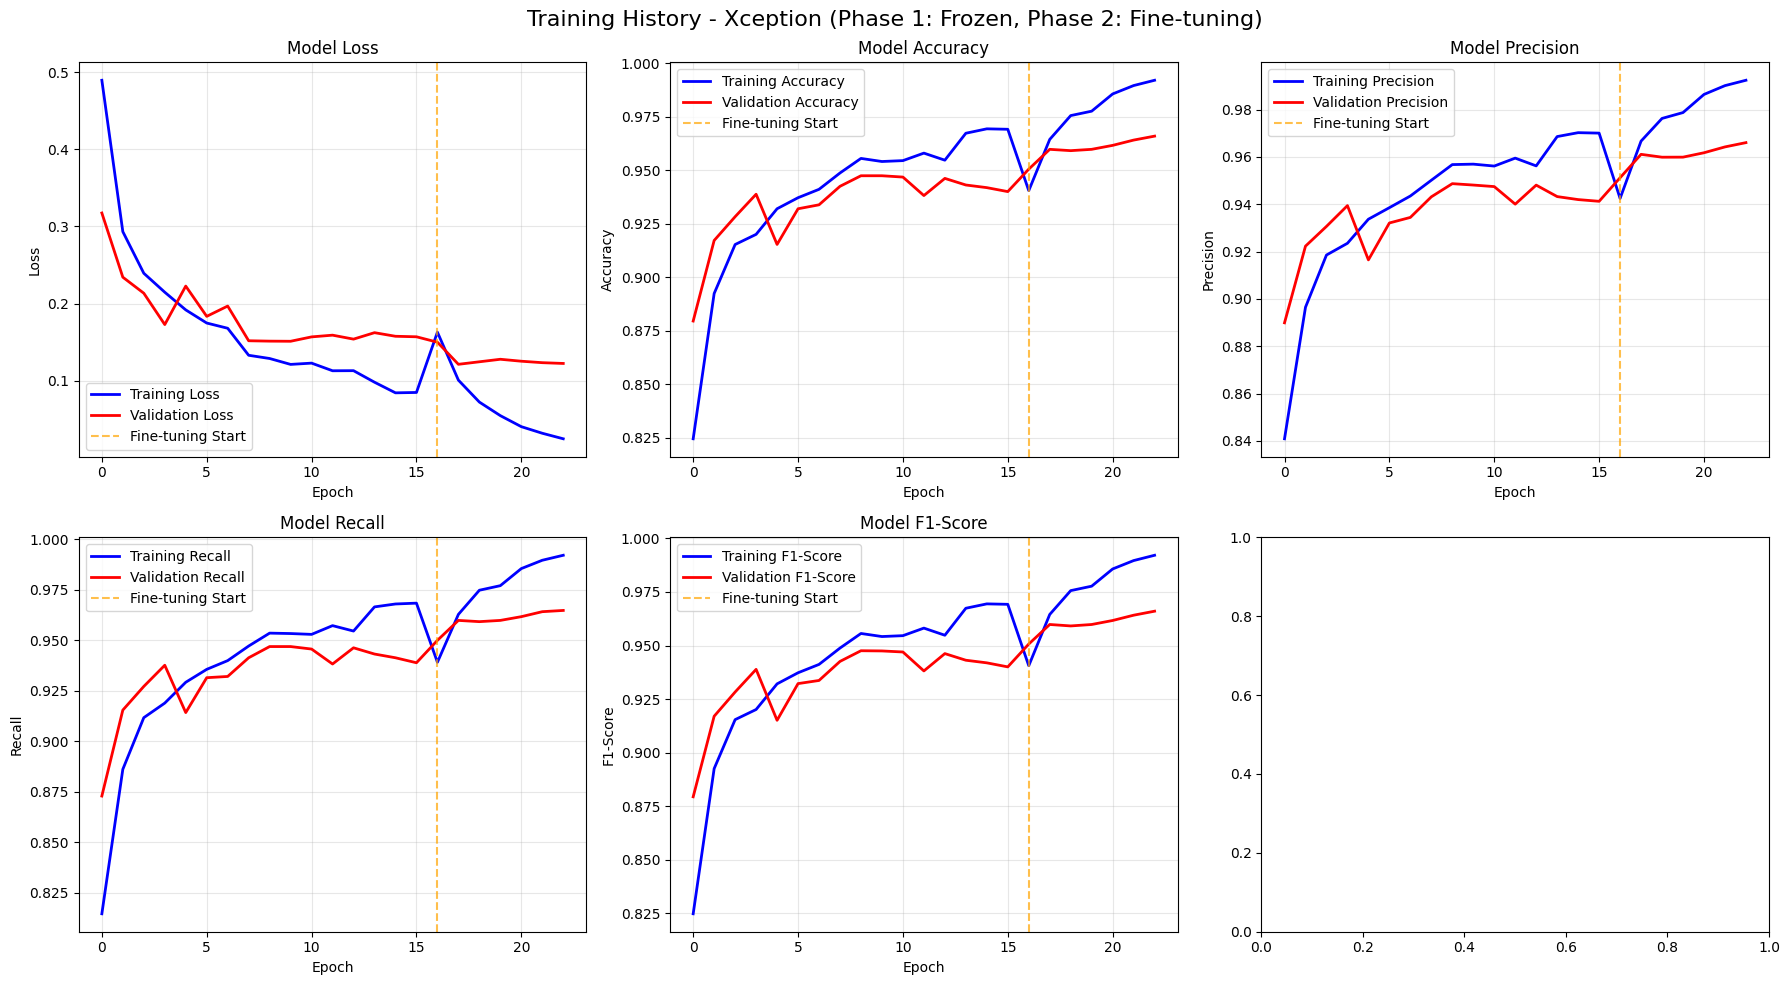

In [29]:
combined_history = plot_combined_training_history(phase1_history, phase2_history)

In [30]:
# -------------------------------
# Evaluation Functions
# -------------------------------
def evaluate_model(model, test_set, class_names):
    """Comprehensive model evaluation"""
    print("\n🧪 Evaluating Model Performance...")
    
    # Basic evaluation
    print("📊 Running Model Evaluation...")
    evaluation_results = model.evaluate(test_set, verbose=1)
    
    # Create a dictionary with metric names and values
    metric_names = ['loss', 'accuracy', 'precision', 'recall', 'f1_score']
    eval_dict = dict(zip(metric_names, evaluation_results))
    
    print("\n📋 Evaluation Results:")
    for metric, value in eval_dict.items():
        print(f"   {metric.capitalize()}: {value:.4f}")
    
    # Predictions for detailed analysis
    print("\n🔍 Generating Predictions...")
    y_true = []
    y_pred = []
    
    for images, labels in test_set:
        # Get true labels
        true_labels = tf.argmax(labels, axis=1)
        y_true.extend(true_labels.numpy())
        
        # Get predictions
        predictions = model.predict(images, verbose=0)
        pred_labels = tf.argmax(predictions, axis=1)
        y_pred.extend(pred_labels.numpy())
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    plot_confusion_matrix(y_true, y_pred, class_names)
    
    return y_true, y_pred, eval_dict

In [31]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Plot detailed confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    
    # Plot regular confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Counts)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    # Calculate normalized confusion matrix
    plt.subplot(1, 2, 2)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlOrBr',
                xticklabels=class_names, 
                yticklabels=class_names)
    plt.title('Confusion Matrix\n(Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    
    plt.tight_layout()
    plt.show()


🧪 Evaluating Model Performance...
📊 Running Model Evaluation...
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9708 - f1_score: 0.9757 - loss: 0.0903 - precision: 0.9713 - recall: 0.9699

2026-03-02 20:08:03.795194: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 20:08:04.044612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 20:08:04.822547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 20:08:05.077748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-02 20:08:06.299347: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 887ms/step - accuracy: 0.9704 - f1_score: 0.9750 - loss: 0.0912 - precision: 0.9709 - recall: 0.9694

📋 Evaluation Results:
   Loss: 0.1135
   Accuracy: 0.9593
   Precision: 0.9610
   Recall: 0.9587
   F1_score: 0.9592

🔍 Generating Predictions...

📋 Detailed Classification Report:
                      precision    recall  f1-score   support

Corona Virus Disease       0.96      0.98      0.97       407
              Normal       0.93      0.96      0.94       404
           Pneumonia       0.96      0.93      0.94       402
        Tuberculosis       0.99      0.98      0.98       408

            accuracy                           0.96      1621
           macro avg       0.96      0.96      0.96      1621
        weighted avg       0.96      0.96      0.96      1621



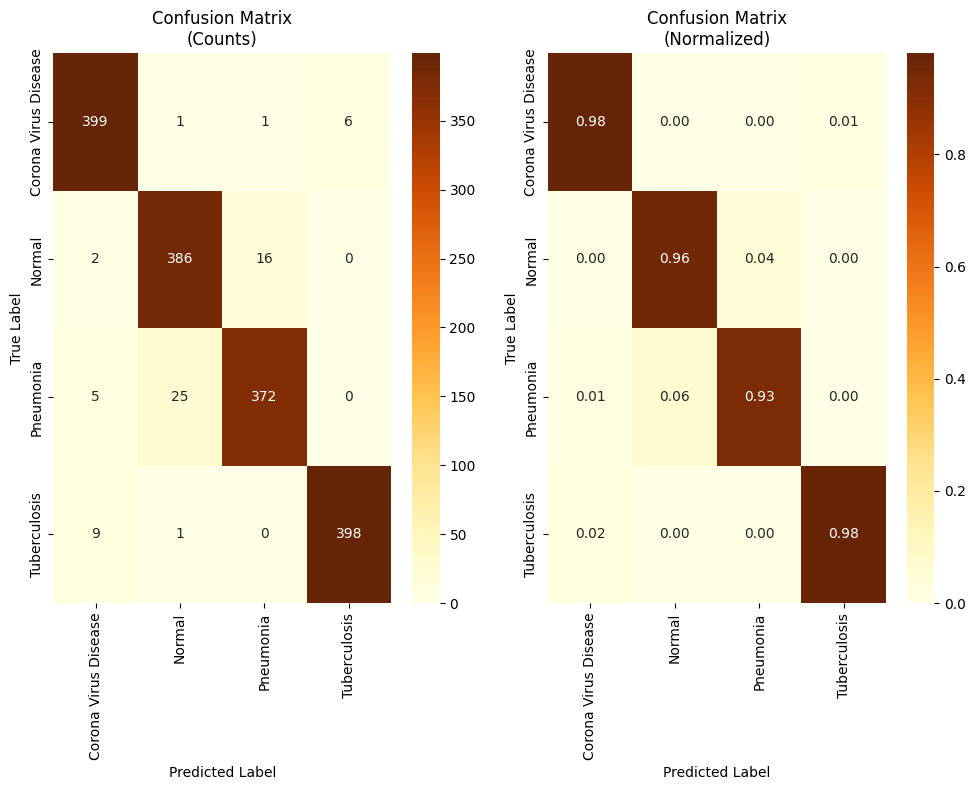

In [32]:
y_true, y_pred, eval_results = evaluate_model(model, test_set, class_names)

In [33]:
print("🎉 Transfer Learning with Xception Completed Successfully!")
print(f"📊 Final Test Accuracy: {eval_results['accuracy']:.2%}")
print(f"📊 Final Test F1-Score: {eval_results['f1_score']:.2%}")

🎉 Transfer Learning with Xception Completed Successfully!
📊 Final Test Accuracy: 95.93%
📊 Final Test F1-Score: 95.92%


In [34]:
print(f"\n📈 Training Summary:")
print(f"   Phase 1 (Frozen): {len(phase1_history.history['loss'])} epochs")
print(f"   Phase 2 (Fine-tuned): {len(phase2_history.history['loss'])} epochs")
print(f"   Total Epochs: {len(phase1_history.history['loss']) + len(phase2_history.history['loss'])}")
print(f"   Fine-tuned from: Layer {fine_tune_at} ({base_model.layers[fine_tune_at].name})")
print(f"   Learning Rate (final): {model.optimizer.learning_rate.numpy():.2e}")


📈 Training Summary:
   Phase 1 (Frozen): 16 epochs
   Phase 2 (Fine-tuned): 7 epochs
   Total Epochs: 23
   Fine-tuned from: Layer 126 (block14_sepconv1)
   Learning Rate (final): 5.00e-05


In [35]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

image_path = "/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Tuberculosis/Tuberculosis-103.jpg"
img = tf.keras.utils.load_img(image_path, target_size=(299,299))
img

x = tf.keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
x.shape

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/epics-lung-disease-dataset/new-lung-disease-dataset/test/Tuberculosis/Tuberculosis-103.jpg'

In [ ]:
pred = model.predict(x)

class_name=['Corona Virus Disease','Normal','Pneumonia', 'Tuberculosis']
result_index = np.argmax(pred)
print("Model Prediction: ", class_name[result_index])